# 2. Data Preparation

> **CRISP-DM Phase 3:** Transform raw data into a clean, merged **Analytical Base Table (ABT)** ready for modelling.

> 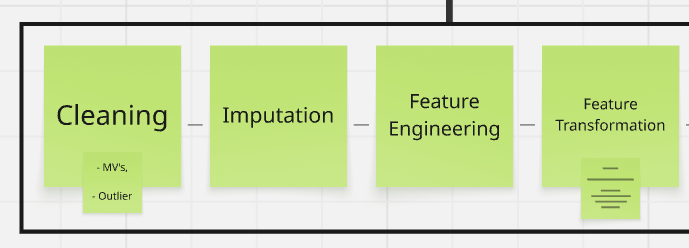

## Table of Contents

- [1.1 Overview](#11-overview)
- [1.2 Setup](#12-setup)
- [2.1 Load Raw Datasets](#21-load-raw-datasets)
- [2.2 Remove Irrelevant Features](#22-remove-irrelevant-features)
- [2.3 Handling Missing Values](#23-handling-missing-values)
- [2.4 Handling Duplicates](#24-handling-duplicates)
- [2.5 Outliers Report](#25-outliers-report)
- [2.6 Merge Datasets → Analytical Base Table (ABT)](#26-merge-datasets--analytical-base-table-abt)
- [2.7 ABT Quality Check](#27-abt-quality-check) (TODO)
- [2.8 Feature Engineering](#28-feature-engineering) (TODO)
- [2.9 Save ABT](#29-save-abt)
- [2.10 Subset ABT for First Objective](#210-subset-abt-for-first-objective) (REVIEW)

## 1.1 Overview

This notebook covers the **Data Preparation** phase of the project, which transforms the raw datasets into a clean, unified **Analytical Base Table (ABT)** ready for feature engineering and modelling.

The preparation is structured into the following steps:

- **2.1 Load Raw Datasets** — load all raw data sources into memory.
- **2.2 Remove Irrelevant Features** — drop columns identified during Data Understanding as having no analytical value, and convert date columns to the correct `datetime` type.
- **2.3 Handling Missing Values** — detect and impute missing values per data type: median for numerics, forward fill for datetimes, and `"Unknown"` for categoricals.
- **2.4 Handling Duplicates** — remove exact duplicate rows and resolve key-level duplicates by keeping the most complete record.
- **2.5 Outliers Report** — flag potential outliers in numeric columns using IQR and Z-score methods. No data is modified at this stage — results are reported for review.
- **2.6 Merge Datasets → ABT** — join the cleaned datasets into a single Analytical Base Table.
- **2.7 ABT Quality Check** — validate the result of the merge: shape, new missing values introduced by the join, and key coverage.
- **2.8 Feature Engineering** — create new variables from existing ones to enrich the ABT for modelling.
- **2.9 Save ABT** — persist the final ABT for use in subsequent notebooks.
- **2.10 Subset ABT for First Objective** — filter and prepare a focused subset of the ABT tailored to the first modelling objective.

To ensure consistency across datasets, steps 2.2 to 2.5 rely on reusable functions defined once and applied to each dataset individually before the merge.

---
## 1.2 Setup

In [1]:
import importlib
import sys, os

# Ensure project root is on path
sys.path.insert(0, os.path.abspath(".."))

import src.code.data_preparation as dp
import src.code.data_functions as dfun
import src.code.io_utils as io

importlib.reload(dp)
importlib.reload(dfun)
importlib.reload(io)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

# Path constants
BDOSS_PATH    = io.data_path("bdoss.csv")
CRC_PATH      = io.data_path("crc.csv")
CREDSCORE_PATH = io.data_path("credscore.csv")
FAMA_PATH     = io.data_path("fama.csv")
ABT_OUT_PATH  = "../data/prepared/abt.parquet"

print("Setup complete.")

Setup complete.


---
## 2.1 Load Raw Datasets

> All four datasets are loaded from the `../data/converted/` folder (CSV format).  
> Loading uses `io_utils.load()`, which prints shape information automatically.

In [2]:
# Main loan-level dataset - large, takes a few seconds to load
bdoss_raw = io.load(BDOSS_PATH)
bdoss_raw.head(3)

[LOAD] /teamspace/studios/this_studio/Business_Case_BNP/data/converted/bdoss.csv | shape: (2658187, 35)


,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,P,CL,EP,0.000,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.000,69.000,69.000,20000.000,20000.000,347.447,NaN,13208.455,0.000,NaN,0.000,0.000,0,0.000,120.000,P,1113.258,80.000,1988.000,P,2845,1.000,A
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,P,CL,EP,0.000,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72.000,34.000,34.000,2500.000,2500.000,56.018,NaN,0.000,0.000,NaN,1.000,1.000,210210000110,0.000,120.000,N,838.186,91.000,1990.000,P,2855,0.000,A
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,P,CL,EP,0.000,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.000,52.000,52.000,5000.000,5000.000,100.074,NaN,2665.191,0.000,NaN,0.000,0.000,0,0.000,118.000,P,1314.144,80.000,2013.000,P,2635,2.000,W


In [3]:
# Credit bureau monthly data
crc_raw = io.load(CRC_PATH)
crc_raw.head(3)

[LOAD] /teamspace/studios/this_studio/Business_Case_BNP/data/converted/crc.csv | shape: (3034921, 22)


,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.000,4.000,0.000,0.000,0.000,1.000,6.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,6842.100,963.550,0.000,0.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,2023-12-31,547.180,4.000,5.000,0.000,0.000,0.000,1.000,10.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,28532.060,7115.460,0.000,0.000
2,0000f858346061c53064586a3347b34659565a6712d004...,2023-12-31,NaN,1.000,5.000,1.000,1.000,0.000,0.000,8.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2957.280,2150.900,2408.560,85549.490


In [ ]:
# Credit score per customer
credscore_raw = io.load(CREDSCORE_PATH)
credscore_raw.head(3)

[LOAD] /teamspace/studios/this_studio/Business_Case_BNP/data/converted/credscore.csv | shape: (63704, 5)


,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,22.000,2025-02-05,H,2.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,4.000,2025-04-09,D,1.000
2,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,1.000,2023-08-08,F,3.000


In [ ]:
# Aggregated customer-level features + socio-demographics
fama_raw = io.load(FAMA_PATH)
fama_raw.head(3)

[LOAD] /teamspace/studios/this_studio/Business_Case_BNP/data/converted/fama.csv | shape: (141115, 23)


,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,2024-11-30,15.000,6.000,9.000,1.000,0.000,88784.040,0.000,88784.040,0.000,4443.000,-808.000,1280.533,0.000,1153.000,1153.000,120.000,0.425,15.000,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f420...,2024-11-30,6.000,4.000,2.000,1.000,2.000,9584.910,7628.410,9584.910,0.000,3120.000,-2077.000,466.333,14.000,1564.667,1582.000,72.000,0.139,6.000,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d0...,2024-11-30,8.000,5.000,3.000,1.000,0.000,22000.860,0.000,22000.860,0.000,4936.000,-2089.000,907.625,0.000,1765.000,1765.000,36.000,0.278,8.000,C,L,65


---
## 2.2 Remove irrelavant features
During the **Data Understanding** phase, we identified across the datasets a set of columns that are not relevant for the analysis and should be dropped, as well as columns stored as strings that represent dates and need to be converted to the correct `datetime` type.
The decisions taken were:

* **Remove columns that were identified as irrelevant** — duplicated identifiers, free-text fields with no analytical value, or internal system columns that carry no signal for the problem at hand.
* **Convert to datetime column**s that represent dates or timestamps but were loaded as strings, so that time-based operations and feature engineering can be applied correctly downstream.

To keep this step consistent and reusable across all datasets, we defined a single function **initial_preparation()** that handles both operations. Columns passed that do not exist in a given dataset are silently ignored, since not all datasets share the same structure.

### 2.2.1 Clean  `bdoss`

In [6]:
datetime_columns_bdoss = ["OBS_DATE", "DCREAT", "DATFIN", "D1FIN", "DPOS", "DCSP"]
drop_columns_bdoss = ["POLE", "TYPEPROD", "PRODALP", "BICONTRATO", "MENSALIDADE_CORR", "ACTIVIDADE_GLOBAL", "AGFIN", "PAGAMENTO", "NATIO", "PPT", "MODCONTACTO"]
bdoss_clean = dp.initial_preparation(df=bdoss_raw, datetime_cols=datetime_columns_bdoss, cols_to_remove=drop_columns_bdoss)

[Dataset]
  Removed   (10)  : ['POLE', 'TYPEPROD', 'PRODALP', 'BICONTRATO', 'MENSALIDADE_CORR', 'ACTIVIDADE_GLOBAL', 'AGFIN', 'PAGAMENTO', 'NATIO', 'MODCONTACTO']
  Datetime  (6) : ['OBS_DATE', 'DCREAT', 'DATFIN', 'D1FIN', 'DPOS', 'DCSP']
  Remaining (25): ['CONTRIB', 'DOSSIER', 'POS', 'OBS_DATE', 'DCREAT', 'DATFIN', 'D1FIN', 'DPOS', 'DURDEG', 'RANGPRO', 'RANGCLI', 'MTFINO', 'MTFIN', 'MENSALIDADE', 'CRD', 'SREC', 'RN', 'RD', 'RISK', 'RISKA', 'RESSO', 'CSP', 'DCSP', 'PTT', 'NBENF']



### 2.2.2 Clean `crc`

In [7]:
datetime_columns_crc = ["OBS_DATE"]
drop_columns_crc = ["COUNT_CP","COUNT_HT","COUNT_CONEXO","COUNT_OTHER","MONTABATV_CP","MONTABATV_CL","MONTABATV_AUTO","MONTABATV_HT"]
crc_clean = dp.initial_preparation(df=crc_raw, datetime_cols=datetime_columns_crc, cols_to_remove=drop_columns_crc)

[Dataset]
  Removed   (8)  : ['COUNT_CP', 'COUNT_HT', 'COUNT_CONEXO', 'COUNT_OTHER', 'MONTABATV_CP', 'MONTABATV_CL', 'MONTABATV_AUTO', 'MONTABATV_HT']
  Datetime  (1) : ['OBS_DATE']
  Remaining (14): ['CONTRIB', 'OBS_DATE', 'MT_MENSAL', 'COUNT_CL', 'COUNT_AUTO', 'COUNT_TOTAL', 'MONTVENC_CL', 'MONTVENC_CP', 'MONTVENC_AUTO', 'MONTVENC_HT', 'DIVIDAS_CL', 'DIVIDAS_CP', 'DIVIDAS_AUTO', 'DIVIDAS_HT']



### 2.2.3 Clean `credscore`

In [ ]:
datetime_columns_credscore = ["sys_data_procura"]
credscore_clean = dp.initial_preparation(df=credscore_raw, datetime_cols=datetime_columns_credscore)

[Dataset]
  Removed   (0)  : —
  Datetime  (1) : ['sys_data_procura']
  Remaining (5): ['CONTRIB', 'sys_numero_submissao', 'sys_data_procura', 'kp_sqe', 'ks_score_tier']



### 2.2.4 Clean `Fama`

In [ ]:
datetime_columns_fama = ["Date_Obs"]
drop_columns_fama = ["ALLBD_N_CL__N", "ALLBD_N_CP__N", "ALLBD_MTFINO_CL__N", "ALLBD_MTFINO_CP__N", "ALLBD_MTFIN_CL__N", "ALLBD_MTFIN_CP__N", "ALLBD_IDADE_MSA__N", "ALLBD_IDADE_MIN__N", "ALLBD_SUM_NUMFIN_CP__N", "ALLBD_mean_active_resso__N", "ALLBD_max_active_resso__N", "ALLBD_mean_duration_CL__N", "ALLBD_mean_lifecycle_CL__N"]
fama_clean = dp.initial_preparation(df=fama_raw, datetime_cols=datetime_columns_fama, cols_to_remove=drop_columns_fama)

[Dataset]
  Removed   (13)  : ['ALLBD_N_CL__N', 'ALLBD_N_CP__N', 'ALLBD_MTFINO_CL__N', 'ALLBD_MTFINO_CP__N', 'ALLBD_MTFIN_CL__N', 'ALLBD_MTFIN_CP__N', 'ALLBD_IDADE_MSA__N', 'ALLBD_IDADE_MIN__N', 'ALLBD_SUM_NUMFIN_CP__N', 'ALLBD_mean_active_resso__N', 'ALLBD_max_active_resso__N', 'ALLBD_mean_duration_CL__N', 'ALLBD_mean_lifecycle_CL__N']
  Datetime  (1) : ['Date_Obs']
  Remaining (10): ['CONTRIB', 'Date_Obs', 'ALLBD_N_Dossiers__N', 'ALLBD_A_CL__N', 'ALLBD_A_CP__N', 'ALLBD_IDADE_MEAN__N', 'ALLBD_N_events__N', 'sdem_SITFAM', 'sdem_HABITAT', 'sdem_age']



### Agreggate bdoss -> client dataset -> client variables

client dataset --- is_chrun --- when -- sun/sol -- when

---
## 2.3 Handling Missing Values

After the initial preparation, we assessed the presence of missing values across all datasets. The goal of this step is to ensure no nulls are carried forward into feature engineering or modelling, as these can cause errors or silently distort results.

The strategy applied follows the data types identified in each dataset:

- **Numeric columns** — imputed with the **median**, which is more robust to outliers than the mean.
- **Datetime columns** — imputed with **forward fill** (`ffill`), propagating the last known date forward. This is appropriate when records have a natural time order and a missing date is likely close to the previous one.
- **Categorical columns** — filled with `"Unknown"`, making the missingness explicit and preserving the row rather than discarding it.
- **Rows** — any row missing more than 50% of its values is dropped before imputation, as imputing heavily incomplete records would introduce more noise than signal.

As with the previous step, a reusable function `handle_missing_values()` was defined and applied consistently across all datasets.

### 2.3.1 Missing Values `Bdoss`


In [10]:
bdoss_clean = dp.handle_missing_values(df= bdoss_clean,dataset_name= "BDOSS")

[BDOSS]
  Missing before     : 294400
  Rows dropped       : 0  (threshold: >50% missing)
  Numeric imputed  (2) [median] : ['RANGCLI', 'NBENF']
  Datetime imputed (1) [ffill]  : ['DCSP']
  Categ.  imputed  (0) [Unknown]  : —
  Missing after      : 0



### 2.3.2 Missing Values `CRC`

In [11]:
crc_clean = dp.handle_missing_values(df= crc_clean,dataset_name= "CRC")

[CRC]
  Missing before     : 2007095
  Rows dropped       : 172  (threshold: >50% missing)
  Numeric imputed  (1) [median] : ['MT_MENSAL']
  Datetime imputed (0) [ffill]  : —
  Categ.  imputed  (0) [Unknown]  : —
  Missing after      : 0



### 2.3.3 Missing Values `CredScore`

In [12]:
credscore_clean= dp.handle_missing_values(df= credscore_clean,dataset_name= "CredScore")


[CredScore]
  Missing before     : 18051
  Rows dropped       : 0  (threshold: >50% missing)
  Numeric imputed  (0) [median] : —
  Datetime imputed (0) [ffill]  : —
  Categ.  imputed  (1) [Unknown]  : ['kp_sqe']
  Missing after      : 0



### 2.3.4 Missing Values `FAMA`

In [13]:
fama_clean= dp.handle_missing_values(df= fama_clean,dataset_name= "Fama")

[Fama]
  Missing before     : 0
  Rows dropped       : 0  (threshold: >50% missing)
  Numeric imputed  (0) [median] : —
  Datetime imputed (0) [ffill]  : —
  Categ.  imputed  (0) [Unknown]  : —
  Missing after      : 0



---
## 2.4 Handling Duplicates

With missing values addressed, we then checked for duplicate records across all datasets. Duplicates can silently distort model training by overrepresenting certain records, so it is important to remove them before moving forward.

We distinguish between two types of duplicates:

- **Exact duplicates** — rows that are completely identical across all columns. These are dropped unconditionally, as they carry no additional information.
- **Key duplicates** — rows that share the same primary key (e.g. `order_id`) but differ in other columns, which can happen due to data ingestion issues or system errors. When found, we keep the row with the fewest missing values, as it is the most complete record.

Note that not all datasets have a single unique key per row by design — for example, a dataset with monthly entries per user will naturally repeat `user_id` across rows. In those cases, `key_cols` is not passed and only exact duplicates are removed.

A reusable function `handle_duplicates()` was defined and applied consistently across all datasets.

### 2.4.1 Duplicates `BDOSS`

In [14]:
bdoss_clean = dp.drop_exact_duplicates(df=bdoss_clean, dataset_name="BDOSS")

[BDOSS]
  Rows before        : 2658187
  Exact duplicates   : 0 dropped
  Rows after         : 2658187



In [15]:
dp.count_key_duplicates(
    df=bdoss_clean,
    dataset_name="BDOSS", 
    key_cols=["CONTRIB", "DOSSIER"]
)

[BDOSS] Key Duplicates Analysis
  Analyzed keys      : ['CONTRIB', 'DOSSIER']
  Key duplicates     : 181955 keys with more than 1 row

  Top duplicated keys:
                                                         CONTRIB                                                          DOSSIER  count
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c62d26faa0207cc5b08 446d96905d26356fb4f1d3e1e6da3868b8106b09a558e61d70dcb3944412ecac     23
fff56d30ec9a1e58be6d34c56c398db0782b4351cb26bd54ecceaf6357e2d1b5 b14858aca84a99262ba0a039dce3cb8075392c1beec89edf7d404e861eb53679     23
fff5ddd56beab05c4edf78f77f859205b3f8f3b6b23b91fa9fcb331f9dbb17bb 7f0752649965b6d91f454a04c9a68e446e184a82b942213627bd31c7d4780f23     23
fff609096cf494f778d94319540d0c03e299be965198f38499eb1d1f4ef9abe8 a51ca431358324029d9168ceebcc2676546d543917f7ea0e378c36190ca61dbf     23
fff66c167f9db5f18178cf0df4190e0e8ac9d3ff25ec0a940eafab8ccfc570f8 ee765aa40e54ca794c0fad3714e4f8215675cfa8e32fc8d8ffeed031133120ab     23



In [28]:
dp.count_key_duplicates(
    df=bdoss_clean,
    dataset_name="BDOSS", 
    key_cols=["CONTRIB"]
)

[BDOSS] Key Duplicates Analysis
  Analyzed keys      : ['CONTRIB']
  Key duplicates     : 146630 keys with more than 1 row

  Top duplicated keys:
                                                         CONTRIB  count
364aad4f1733591b129753f295cca317a449f207c209bdc4db94c94e6646dde6    158
f4aa11c8d15eaeffbc03901f3c4d216c393a556a8d6b28af46444324919b6049    149
5f41a41cb0cd7845520ce973ccad221fd021bd99e225d528425b81b91457b38e    146
a1262815dfba6d51fa3a1c0e1cbeea98cd81c570888021a9abf65cb9a29edc78    127
3210ff76ce810986703e5a75b4e9c5c70ad893e70aba22b9b1268c6a33c3fea1    125



### 2.4.2 Duplicates `CRC`

In [16]:
crc_clean = dp.drop_exact_duplicates(df=crc_clean,dataset_name= "CRC")

[CRC]
  Rows before        : 3034749
  Exact duplicates   : 0 dropped
  Rows after         : 3034749



In [17]:
dp.count_key_duplicates(
    df=crc_clean,
    dataset_name="CRC", 
    key_cols=["CONTRIB"]
)

[CRC] Key Duplicates Analysis
  Analyzed keys      : ['CONTRIB']
  Key duplicates     : 140580 keys with more than 1 row

  Top duplicated keys:
                                                         CONTRIB  count
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b     25
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981     25
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297     25
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed     25
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c62d26faa0207cc5b08     25



### 2.4.3 Duplicates `CredScore`


In [18]:
credscore_clean = dp.drop_exact_duplicates(df=credscore_clean,dataset_name= "CredScore")

[CredScore]
  Rows before        : 63704
  Exact duplicates   : 831 dropped
  Rows after         : 62873



In [19]:
dp.count_key_duplicates(
    df=credscore_clean,
    dataset_name="CredScore", 
    key_cols=["CONTRIB"]
)

[CredScore] Key Duplicates Analysis
  Analyzed keys      : ['CONTRIB']
  Key duplicates     : 654 keys with more than 1 row

  Top duplicated keys:
                                                         CONTRIB  count
0327b5a9a23ce7ae7b9256d3d823ad083b8f499400d8b9fcc73203df81780557     19
8113d0317706260e28dfec304fa038275b4fc15623de861124c2d5add6ee3876      6
827978bec96df43727652811a874ccf1b825026900c457c6dbdc9bd10465db6e      6
f47a17aafacd0a149d5995c3179a165ba0b2243f33e573a4ece56af9ffd8b708      5
9d8a2ebf8953fa786c9d41bb8750cba86acbd52ae3430540879505b403a440d1      4



### 2.4.4 Duplicates `FAMA`


In [20]:
fama_clean = dp.drop_exact_duplicates(df=fama_clean,dataset_name= "FAMA")

[FAMA]
  Rows before        : 141115
  Exact duplicates   : 0 dropped
  Rows after         : 141115



In [21]:
dp.count_key_duplicates(
    df=fama_clean,
    dataset_name="FAMA", 
    key_cols=["CONTRIB"]
)

[FAMA] Key Duplicates Analysis
  Analyzed keys      : ['CONTRIB']
  Key duplicates     : 0 keys with more than 1 row



---
## 2.5 Outliers Report

Before merging the datasets, we ran outlier detection on all numeric columns. At this stage the goal is purely diagnostic — no data is modified. The decision on how to handle each outlier (remove, cap, or leave) will be made in context, after reviewing the results and considering the modelling approach to be used downstream.

Two complementary methods were applied:

- **IQR (Interquartile Range)** — flags values that fall below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR`. More robust to skewed distributions and effective at catching extreme values relative to the bulk of the data.
- **Z-score** — flags values more than 3 standard deviations from the mean. Works best on roughly normal distributions and is more sensitive to moderate but consistent deviations.

Using both methods together gives a fuller picture: a value flagged by both is almost certainly a true outlier, while one flagged by only one method may warrant a closer look.

The function `detect_outliers()` reports the count and percentage of flagged rows per column but does not return a modified DataFrame.

### 2.5.1 Outliers Summary  `BDOSS`

In [22]:
dp.detect_outliers(df=bdoss_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------
  DURDEG                             14290                 0     0.5%
  RANGPRO                             6515              5353     0.2%
  RANGCLI                            39691              7447     1.5%
  MTFINO                            146804             52980     5.5%
  MTFIN                             146819             52980     5.5%
  MENSALIDADE                       160645             53334     6.0%
  CRD                               171314             56624     6.4%
  SREC                              167187              6590     6.3%
  RN                                387888            130518    14.6%
  RD                                387270            104238    14.6%
  RISKA                              87031              7954     3.3%
  RESSO                             162979               894  

### 2.5.2 Outliers Summary  `CRC`

In [23]:
dp.detect_outliers(df=crc_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------


  MT_MENSAL                        1029612              1079    33.9%
  COUNT_CL                          282883             41934     9.3%
  COUNT_AUTO                         52941             52941     1.7%
  COUNT_TOTAL                        93557             40653     3.1%
  MONTVENC_CL                       114199              8806     3.8%
  MONTVENC_CP                       135750             18423     4.5%
  MONTVENC_AUTO                      37100              4492     1.2%
  MONTVENC_HT                        18812              1168     0.6%
  DIVIDAS_CL                        179156             44137     5.9%
  DIVIDAS_CP                        260289             53124     8.6%
  DIVIDAS_AUTO                      216230             53895     7.1%
  DIVIDAS_HT                        242697             51047     8.0%
  ------------------------- -------------- ----------------- --------
  TOTAL                            2663226            371699



### 2.5.3 Outliers Summary  `CredScore`

In [24]:
dp.detect_outliers(df=credscore_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------
  sys_numero_submissao                1724               731     2.7%
  ks_score_tier                        856               277     1.4%
  ------------------------- -------------- ----------------- --------
  TOTAL                               2580              1008



### 2.5.4 Outliers Summary  `FAMA`

In [25]:
dp.detect_outliers(df=fama_clean)

[Dataset] Outlier Detection
  Column                      IQR outliers  Z-score outliers   % rows
  ------------------------- -------------- ----------------- --------
  ALLBD_N_Dossiers__N                 5393              2073     3.8%
  ALLBD_A_CL__N                       1347              1347     1.0%
  ALLBD_A_CP__N                       3626               554     2.6%
  ALLBD_IDADE_MEAN__N                 1613               885     1.1%
  ALLBD_N_events__N                   5393              2073     3.8%
  sdem_age                              33                23     0.0%
  ------------------------- -------------- ----------------- --------
  TOTAL                              17405              6955



---
## 2.6 Merge Datasets $\rightarrow$ Analytical Base Table (ABT)

Join strategy:
```
bdoss (base)   LEFT JOIN  crc        ON [CONTRIB, OBS_DATE]
               LEFT JOIN  credscore  ON [CONTRIB]
               LEFT JOIN  fama       ON [CONTRIB]
```
Using **left join** ensures we keep all bdoss records even if bureau/score data is missing for some customers.

In [26]:
abt = dp.merge_datasets(bdoss_clean, crc_clean, credscore_clean, fama_clean)

print(f"\nFinal ABT shape: {abt.shape}")
display(abt.head(3))

[merge] Starting merge...


[merge] Final ABT shape: (2669938, 50)
[merge] Overall missing: 6.34%
[merge] RISK distribution:
{0: 2335051, 444444444444444444444444: 23995, 1: 16693, 10: 7537, 100: 6300, 1000: 5454, 10000: 5210, 100000: 4768, 1000000: 4378, 10000000: 3989, 100000000: 3791, 11: 3485, 1000000000: 3477, 10000000000: 3403, 100000000000: 3215, 1000000000000: 3193, 10000000000000: 2870, 1000000000000000: 2745, 100000000000000: 2694, 10000000000000000: 2490, 100000000000000000: 2431, 1000000000000000000: 2412, 100000000000000000000: 2104, 10000000000000000000: 2086, 1000000000000000000000: 2086, 10000000000000000000000: 1960, 100000000000000000000000: 1545, 212: 1294, 111111111111111111111111: 1028, 12: 990, 2: 949, 120: 756, 110: 745, 111: 711, 101: 667, 1001: 642, 1200: 611, 1100: 579, 12000: 559, 10001: 536, 120000: 490, 11000: 468, 110000: 433, 100001: 413, 1220: 401, 1100000: 393, 122: 383, 1200000: 370, 10000001: 365, 1000001: 348, 200: 345, 11000000: 336, 22: 334, 2122: 334, 120000000: 324, 12200: 

,CONTRIB,DOSSIER,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,CRD,SREC,RN,RD,RISK,RISKA,RESSO,CSP,DCSP,PTT,NBENF,MT_MENSAL,COUNT_CL,COUNT_AUTO,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_IDADE_MEAN__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.000,69.000,69.000,20000.000,20000.000,347.447,13208.455,0.000,0.000,0.000,0,0.000,1113.258,80.000,1970-01-01 00:00:00.000001988,2845,1.000,547.450,4.000,0.000,10.000,0.000,0.000,0.000,0.000,28222.690,7162.060,0.000,0.000,4.000,2025-04-09,D,1.000,2024-11-30,10.000,1.000,0.000,1166.900,10.000,C,P,52.000
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72.000,34.000,34.000,2500.000,2500.000,56.018,0.000,0.000,1.000,1.000,210210000110,0.000,838.186,91.000,1970-01-01 00:00:00.000001990,2855,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,2024-11-30,3.000,0.000,0.000,590.333,3.000,S,A,69.000
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.000,52.000,52.000,5000.000,5000.000,100.074,2665.191,0.000,0.000,0.000,0,0.000,1314.144,80.000,1970-01-01 00:00:00.000002013,2635,2.000,446.650,1.000,1.000,8.000,0.000,0.000,0.000,0.000,2883.360,2119.750,2346.150,85494.100,NaN,NaT,NaN,NaN,2024-11-30,4.000,1.000,1.000,1358.250,4.000,U,A,39.000


# IMPORTANT NOTE:
Some client dont have values because they not existe in the main table, so this is the type of dicision that we need to think how we are going to handle it before moving to the FE

---
## 2.7 ABT Quality Check (ERROR ITS NORMAL)

Verify:
- No column is 100% null
- `RISK` is a clean binary integer
- Overall missing-value rate is acceptable

In [27]:
# Assertions 
assert abt.shape[0] > 0, "ABT is empty!"
assert "RISK" in abt.columns, "RISK column missing!"
assert abt["RISK"].isin([0, 1]).all(), "RISK is not binary!"
assert abt["RISK"].isnull().sum() == 0, "RISK has nulls!"
assert (abt.isnull().mean() < 1.0).all(), "Some column is 100% null!"

print("All assertions passed.")

AssertionError: RISK is not binary!

In [ ]:
# Missing values overview
null_pct = (abt.isnull().sum() / len(abt) * 100).round(2)
null_summary = null_pct[null_pct > 0].sort_values(ascending=False)
print(f"Columns with missing values ({len(null_summary)} / {abt.shape[1]}):")
if len(null_summary) > 0:
    display(null_summary.to_frame("null_pct"))
else:
    print("None! ABT is fully complete")

overall_null = abt.isnull().sum().sum() / abt.size * 100
print(f"\nOverall missing: {overall_null:.2f}%")

In [ ]:
# RISK class balance
risk_counts = abt["RISK"].value_counts().sort_index()
labels = ["0 - No Risk", "1 - Risk"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(labels, risk_counts.values, color=["steelblue", "tomato"], edgecolor="white")
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 2000, f"{v:,}\n({v / risk_counts.sum() * 100:.1f}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("RISK Distribution - ABT", fontsize=12)
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(risk_counts.values, labels=labels,
            colors=["steelblue", "tomato"], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("RISK Class Balance", fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio (risk:no-risk): 1:{risk_counts[0] / risk_counts[1]:.1f}")

In [ ]:
# Data types summary
dtype_counts = abt.dtypes.value_counts()
print("Column dtype distribution:")
display(dtype_counts.to_frame("count"))

# List any remaining object columns (should be only CONTRIB)
obj_cols = abt.select_dtypes(include="object").columns.tolist()
print(f"\nRemaining object columns: {obj_cols}")

In [ ]:
# Feature overview
print(f"Total features in ABT: {abt.shape[1]}")
print("\nAll columns:")
for i, col in enumerate(abt.columns, 1):
    print(f"  {i:3d}. {col}")

## 2.8 Feature engineering (TODO)


### After this process we can pass to the cool parte, encoding, scaling anddddddddd THE MODELSSSSSSSSSSS RAHHHHHHHHHHHHHH (Its 1:26 im so tired)

---
## 2.9 Save ABT

The ABT is saved as a **Parquet file** to `../data/prepared/abt.parquet`.  
Parquet preserves dtypes and is significantly faster to read than CSV for large tables.

In [ ]:
io.save(abt, ABT_OUT_PATH)

# Verify file exists and reload sanity check
import os
assert os.path.exists(ABT_OUT_PATH), "ABT file not found after save!"

abt_check = pd.read_parquet(ABT_OUT_PATH)
assert abt_check.shape == abt.shape, "Reloaded shape mismatch!"
print(f"\nABT successfully saved and verified: {ABT_OUT_PATH}")
print(f"   Rows: {abt_check.shape[0]:,}  |  Columns: {abt_check.shape[1]}")

---
## 2.10 Subset ABT for First Objective (NEED Review)

Keep only customers whose **point-of-sale channel** is `SAN` or `SOL`, then create a binary flag `IS_SAN` (1 = SAN, 0 = SOL) to act as group identifier for the first modelling objective.

> **Note:** `POS` was one-hot encoded in step 2.2, so the original string column no longer exists in the ABT.  
> We reconstruct the filter from the `POS_SAN` and `POS_SOL` dummy columns.

In [ ]:
# Keep only SAN and SOL rows (both dummy cols must exist in the ABT)
assert "POS_SAN" in abt.columns and "POS_SOL" in abt.columns, \
    "POS_SAN / POS_SOL columns not found – re-run earlier cells first."

mask = (abt["POS_SAN"] == 1) | (abt["POS_SOL"] == 1)
abt_first_objective = abt.loc[mask].copy()

# Binary flag: 1 if SAN, 0 if SOL
abt_first_objective["IS_SAN"] = abt_first_objective["POS_SAN"].astype(int)

print(f"Original ABT rows : {abt.shape[0]:>10,}")
print(f"abt_first_objective rows: {abt_first_objective.shape[0]:>10,}  "
      f"({abt_first_objective.shape[0] / abt.shape[0] * 100:.1f}% of ABT)")
print(f"\nIS_SAN distribution:")
print(abt_first_objective["IS_SAN"].value_counts().rename({1: "SAN", 0: "SOL"}))

In [ ]:
abt_first_objective
abt_first_objective[abt_first_objective["CONTRIB"] == "00245abdde6b5be044bd121c4618fdcc43e90f9f0ef5bccd4bf8dce4665e2303"
]

In [ ]:
ABT_FIRST_OUT_PATH = "../data/prepared/abt_first_objective.parquet"
io.save(abt_first_objective, ABT_FIRST_OUT_PATH)

import os
assert os.path.exists(ABT_FIRST_OUT_PATH), "File not written!"
print(f"Saved → {ABT_FIRST_OUT_PATH}")
print(f"Shape: {abt_first_objective.shape}")